In [3]:
import pandas as pd
import glob

# Read all CSV files matching your pattern
files = glob.glob("test*.csv")
print(files)
# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Filter for distance = 10 km
df_10km = all_data[all_data["distance"] == 10]

weighted_fidelities = {}
weighted_retries = {}
weighted_rates = {}
success_fractions = {}

runs_per_repeater = 4500  # each repeater case has 10,000 iterations

for r in [1, 2, 3, 4, 5, 6, 7, 8]:
    df_r = df_10km[df_10km["num_repeaters"] == r]
    if not df_r.empty:
        # Weighted fidelity for this repeater case
        weighted_fid = (df_r["fidelity"] * df_r["num_success"]).sum() / df_r["num_success"].sum()
        weighted_ret = (df_r["retries"] * df_r["num_success"]).sum() / df_r["num_success"].sum()
        # weighted_rate = (df_r["rate"] * df_r["num_success"]).sum() / df_r["num_success"].sum()
        print(weighted_fid)
        weighted_fidelities[r] = weighted_fid
        weighted_retries[r] = weighted_ret
        # weighted_rates[r] = weighted_rate
        print(weighted_fidelities)

        # Success probability (normalized by total runs)
        total_success = df_r["num_success"].sum()
        success_fractions[r] = total_success / runs_per_repeater

print("=== 10 km Results ===")
for r in [1, 2, 3, 4, 5, 6, 7, 8]:
    if r in weighted_fidelities:
        print(f"Repeaters {r}:")
        print(f"  Weighted Fidelity = {weighted_fidelities[r]:.3f}")
        # print(f"  Weighted Rate = {weighted_rates[r]:.3f}")
        print(f"  Success Fraction  = {success_fractions[r]:.6f}")
        print(f"  Weighted Retries = {weighted_retries[r]:.3f}")

['test3.csv', 'test1.csv', 'test2.csv']
0.8224913941480206
{1: 0.8224913941480206}
0.7364416159380187
{1: 0.8224913941480206, 2: 0.7364416159380187}
0.6741532258064514
{1: 0.8224913941480206, 2: 0.7364416159380187, 3: 0.6741532258064514}
0.6062969432314411
{1: 0.8224913941480206, 2: 0.7364416159380187, 3: 0.6741532258064514, 4: 0.6062969432314411}
0.5646465696465697
{1: 0.8224913941480206, 2: 0.7364416159380187, 3: 0.6741532258064514, 4: 0.6062969432314411, 5: 0.5646465696465697}
0.511491344873502
{1: 0.8224913941480206, 2: 0.7364416159380187, 3: 0.6741532258064514, 4: 0.6062969432314411, 5: 0.5646465696465697, 6: 0.511491344873502}
0.4857425742574257
{1: 0.8224913941480206, 2: 0.7364416159380187, 3: 0.6741532258064514, 4: 0.6062969432314411, 5: 0.5646465696465697, 6: 0.511491344873502, 7: 0.4857425742574257}
0.4466033755274262
{1: 0.8224913941480206, 2: 0.7364416159380187, 3: 0.6741532258064514, 4: 0.6062969432314411, 5: 0.5646465696465697, 6: 0.511491344873502, 7: 0.4857425742574257,

In [2]:
import pandas as pd
import glob

# Read all CSV files matching your pattern
files = glob.glob("test*.csv")

# Initialize dictionary to accumulate sums
rate_sums = {r: 0.0 for r in range(1, 9)}
count_files = {r: 0 for r in range(1, 9)}

for f in files:
    df = pd.read_csv(f)
    df_10km = df[df["distance"] == 10]
    
    for r in range(1, 9):
        df_r = df_10km[df_10km["num_repeaters"] == r]
        if not df_r.empty:
            rate_sum_for_file = df_r["rate"].sum()  # sum all rates in this file for this repeater
            rate_sums[r] += rate_sum_for_file
            count_files[r] += 1

# Compute simple average across files
final_rates = {r: rate_sums[r]/count_files[r] for r in rate_sums if count_files[r] > 0}

print("Average rate per repeater across files:")
for r, rate in final_rates.items():
    print(f"Repeaters {r}: {rate:.3f}")


Average rate per repeater across files:
Repeaters 1: 30.031
Repeaters 2: 23.616
Repeaters 3: 18.893
Repeaters 4: 14.729
Repeaters 5: 12.224
Repeaters 6: 9.743
Repeaters 7: 7.864
Repeaters 8: 6.248


In [ ]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("retries/ret*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 54000
distances = [20, 40, 80, 160]
retries_list = [30, 60, 90, 120]
num_repeaters = 1

records = []

for dist in distances:
    for retries in retries_list:
        df_case = all_data[
            (all_data["distance"] == dist)
            & (all_data["retries"] == retries)
            & (all_data["num_repeaters"] == num_repeaters)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                "distance": dist,
                "retries": retries,
                "num_repeaters": num_repeaters,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                "retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)

# Sort nicely
result_df = result_df.sort_values(by=["distance", "retries"]).reset_index(drop=True)

# Save to CSV
output_folder = "retries"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "results_by_distance_retries.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)

In [ ]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("rate_fid/rate_fid*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 22500
distances = sorted(all_data["distance"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for dist in distances:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["distance"] == dist)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                "distance": dist,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)

# Sort nicely
result_df = result_df.sort_values(by=["distance", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "rate_fid"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "results_all_distances_repeaters.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)

In [38]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("rate/coll_eff*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 15000
coll_eff = sorted(all_data["collection_efficiency"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for col in coll_eff:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["collection_efficiency"] == col)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "collection_efficiency": col,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)

# Sort nicely
result_df = result_df.sort_values(by=["collection_efficiency", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "rate"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_coll_eff.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)


Found files: ['rate/coll_eff1.csv', 'rate/coll_eff10.csv', 'rate/coll_eff3.csv', 'rate/coll_eff5.csv', 'rate/coll_eff2.csv', 'rate/coll_eff8.csv', 'rate/coll_eff7.csv', 'rate/coll_eff9.csv', 'rate/coll_eff6.csv', 'rate/coll_eff4.csv']
✅ Aggregated results saved to rate/agg_coll_eff.csv
    collection_efficiency  num_repeaters  fidelity       sem       rate  \
0                     0.6              1  0.793573  0.006312   4.824141   
1                     0.6              4  0.574418  0.010265   3.794576   
2                     0.6              8  0.432096  0.011206   1.612148   
3                     0.7              1  0.794270  0.004803   7.894688   
4                     0.7              4  0.581579  0.005923   9.014979   
5                     0.7              8  0.440119  0.005384   5.950725   
6                     0.8              1  0.801188  0.003587  11.286734   
7                     0.8              4  0.591114  0.004158  15.869358   
8                     0.8             

In [40]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("rate/fib_loss*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 7500
ph_loss = sorted(all_data["photon_loss"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for ph in ph_loss:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["photon_loss"] == ph)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "photon_loss": ph,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)
# print(result_df.head())

# Sort nicely
result_df = result_df.sort_values(by=["photon_loss", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "rate"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_fib_loss.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)


Found files: ['rate/fib_loss4.csv', 'rate/fib_loss1.csv', 'rate/fib_loss3.csv', 'rate/fib_loss2.csv', 'rate/fib_loss5.csv']
✅ Aggregated results saved to rate/agg_fib_loss.csv
   photon_loss  num_repeaters  fidelity       sem       rate  success_fraction
0          0.1              1  0.801209  0.003202  15.763169          0.434533
1          0.1              4  0.583724  0.004737  14.057740          0.311867
2          0.1              8  0.442529  0.004291   8.533623          0.171867
3          0.2              1  0.793865  0.004928   7.332922          0.210800
4          0.2              4  0.580303  0.006413   8.415735          0.184933
5          0.2              8  0.436935  0.005604   5.521841          0.109200
6          0.3              1  0.798018  0.006282   3.074042          0.088133
7          0.3              4  0.579792  0.008228   4.759375          0.102533
8          0.3              8  0.431054  0.007583   3.452181          0.067067


In [41]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("rate/proto_sched*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 6000
proto_sched = sorted(all_data["proto_sched"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for proto in proto_sched:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["proto_sched"] == proto)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "proto_sched": proto,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)
# print(result_df.head())

# Sort nicely
result_df = result_df.sort_values(by=["proto_sched", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "rate"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_proto_sched.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)


Found files: ['rate/proto_sched3.csv', 'rate/proto_sched1.csv', 'rate/proto_sched4.csv', 'rate/proto_sched2.csv']
✅ Aggregated results saved to rate/agg_proto_sched.csv
   proto_sched  num_repeaters  fidelity       sem      rate  success_fraction
0            1              1  0.797201  0.004712  7.413136          0.213167
1            1              4  0.581264  0.006450  8.174184          0.179333
2            1              8  0.435833  0.005812  5.757731          0.114000
3            3              1  0.795551  0.004867  7.627235          0.217667
4            3              4  0.495195  0.009636  5.657692          0.192167
5            3              8  0.344706  0.009241  2.638892          0.104833


In [42]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("fidelity/ct*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 6000
c_times = sorted(all_data["coherence_time"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for ct in c_times:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["coherence_time"] == ct)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "coherence_time": ct,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)
# print(result_df.head())

# Sort nicely
result_df = result_df.sort_values(by=["coherence_time", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "fidelity"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_ct.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)


Found files: ['fidelity/ct3.csv', 'fidelity/ct2.csv', 'fidelity/ct1.csv', 'fidelity/ct4.csv']
✅ Aggregated results saved to fidelity/agg_ct.csv
    coherence_time  num_repeaters  fidelity       sem      rate  \
0         60000000              1  0.795460  0.004604  7.294320   
1         60000000              4  0.580302  0.006258  8.296239   
2         60000000              8  0.432979  0.006134  5.557420   
3        100000000              1  0.824858  0.001850  7.555913   
4        100000000              4  0.625671  0.002956  8.514928   
5        100000000              8  0.473142  0.002643  5.435319   
6        150000000              1  0.833514  0.000950  7.309843   
7        150000000              4  0.642959  0.001404  8.403448   
8        150000000              8  0.486704  0.001498  5.942616   
9        200000000              1  0.836514  0.000536  7.470129   
10       200000000              4  0.649685  0.000923  8.188304   
11       200000000              8  0.491587  0.00088

In [43]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("fidelity/em_fid*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 6000
em_fid = sorted(all_data["emission_fidelity"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for em in em_fid:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["emission_fidelity"] == em)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "emission_fidelity": em,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)
# print(result_df.head())

# Sort nicely
result_df = result_df.sort_values(by=["emission_fidelity", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "fidelity"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_em_fid.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)

Found files: ['fidelity/em_fid4.csv', 'fidelity/em_fid3.csv', 'fidelity/em_fid2.csv', 'fidelity/em_fid1.csv']
✅ Aggregated results saved to fidelity/agg_em_fid.csv
    emission_fidelity  num_repeaters  fidelity       sem      rate  \
0                0.96              1  0.797660  0.004365  7.695545   
1                0.96              4  0.578044  0.006677  7.984427   
2                0.96              8  0.432692  0.006108  5.383458   
3                0.97              1  0.829138  0.005071  7.317820   
4                0.97              4  0.630586  0.007386  7.899017   
5                0.97              8  0.496672  0.006814  5.576895   
6                0.98              1  0.862841  0.005485  7.290624   
7                0.98              4  0.689210  0.008360  8.168042   
8                0.98              8  0.551729  0.010102  5.400634   
9                0.99              1  0.898308  0.005640  7.318737   
10               0.99              4  0.755247  0.008752  8.265397

In [44]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("rate/qfc*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 7500
em_fid = sorted(all_data["init_photon_loss"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for em in em_fid:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["init_photon_loss"] == em)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "init_photon_loss": em,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)
# print(result_df.head())

# Sort nicely
result_df = result_df.sort_values(by=["init_photon_loss", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "rate"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_qfc.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)

Found files: ['rate/qfc3.csv', 'rate/qfc4.csv', 'rate/qfc5.csv', 'rate/qfc1.csv', 'rate/qfc2.csv']
✅ Aggregated results saved to rate/agg_qfc.csv
    init_photon_loss  num_repeaters  fidelity       sem       rate  \
0                0.1              1  0.830904  0.000760  64.821267   
1                0.1              4  0.650115  0.000452  82.231139   
2                0.1              8  0.493153  0.000269  85.334933   
3                0.2              1  0.826408  0.001070  57.567126   
4                0.2              4  0.646522  0.000599  76.104779   
5                0.2              8  0.490441  0.000373  79.704748   
6                0.3              1  0.820041  0.001504  48.926879   
7                0.3              4  0.638834  0.000947  68.815554   
8                0.3              8  0.485196  0.000594  72.447998   
9                0.4              1  0.816578  0.001634  38.853236   
10               0.4              4  0.627391  0.001404  58.758306   
11            

In [45]:
import pandas as pd
import glob
import os

# Read all CSV files matching your pattern
files = glob.glob("fidelity/ms_fid*.csv")
print("Found files:", files)

# Combine all into one dataframe
all_data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Parameters
runs_per_repeater = 6000
em_fid = sorted(all_data["ms_depolar_prob"].unique())
num_repeaters_list = sorted(all_data["num_repeaters"].unique())

records = []

for em in em_fid:
    for nr in num_repeaters_list:
        df_case = all_data[
            (all_data["ms_depolar_prob"] == em)
            & (all_data["num_repeaters"] == nr)
        ]

        if not df_case.empty:
            total_success = df_case["num_success"].sum()

            # Weighted fidelity and weighted retries
            weighted_fid = (df_case["fidelity"] * df_case["num_success"]).sum() / total_success
            # weighted_ret = (df_case["retries"] * df_case["num_success"]).sum() / total_success

            # Weighted SEM
            weighted_sem = (df_case["sem"] * df_case["num_success"]).sum() / total_success

            # Average (normal mean) rate
            avg_rate = df_case["rate"].mean()

            # Success fraction (normalized)
            success_frac = total_success / runs_per_repeater

            records.append({
                # "distance": dist,
                "ms_depolar_prob": em,
                "num_repeaters": nr,
                "fidelity": weighted_fid,
                "sem": weighted_sem,
                # "weighted_retries": weighted_ret,
                "rate": avg_rate,
                "success_fraction": success_frac
            })

# Create dataframe from results
result_df = pd.DataFrame(records)
# print(result_df.head())

# Sort nicely
result_df = result_df.sort_values(by=["ms_depolar_prob", "num_repeaters"]).reset_index(drop=True)

# Save to CSV
output_folder = "fidelity"
os.makedirs(output_folder, exist_ok=True)
output_file = os.path.join(output_folder, "agg_ms_fid.csv")
result_df.to_csv(output_file, index=False)

print(f"✅ Aggregated results saved to {output_file}")
print(result_df)

Found files: ['fidelity/ms_fid1.csv', 'fidelity/ms_fid3.csv', 'fidelity/ms_fid2.csv', 'fidelity/ms_fid4.csv']
✅ Aggregated results saved to fidelity/agg_ms_fid.csv
    ms_depolar_prob  num_repeaters  fidelity       sem      rate  \
0              0.05              1  0.765223  0.004858  7.551256   
1              0.05              4  0.512065  0.005348  8.406006   
2              0.05              8  0.366826  0.004329  5.665782   
3              0.06              1  0.758749  0.005015  7.082580   
4              0.06              4  0.497602  0.005178  8.563863   
5              0.06              8  0.354886  0.003765  5.862813   
6              0.07              1  0.750225  0.004602  7.196741   
7              0.07              4  0.482274  0.005108  7.872941   
8              0.07              8  0.341070  0.003798  5.535538   
9              0.08              1  0.748824  0.004324  7.266857   
10             0.08              4  0.472573  0.004694  8.100891   
11             0.08 

## QFC Efficiency

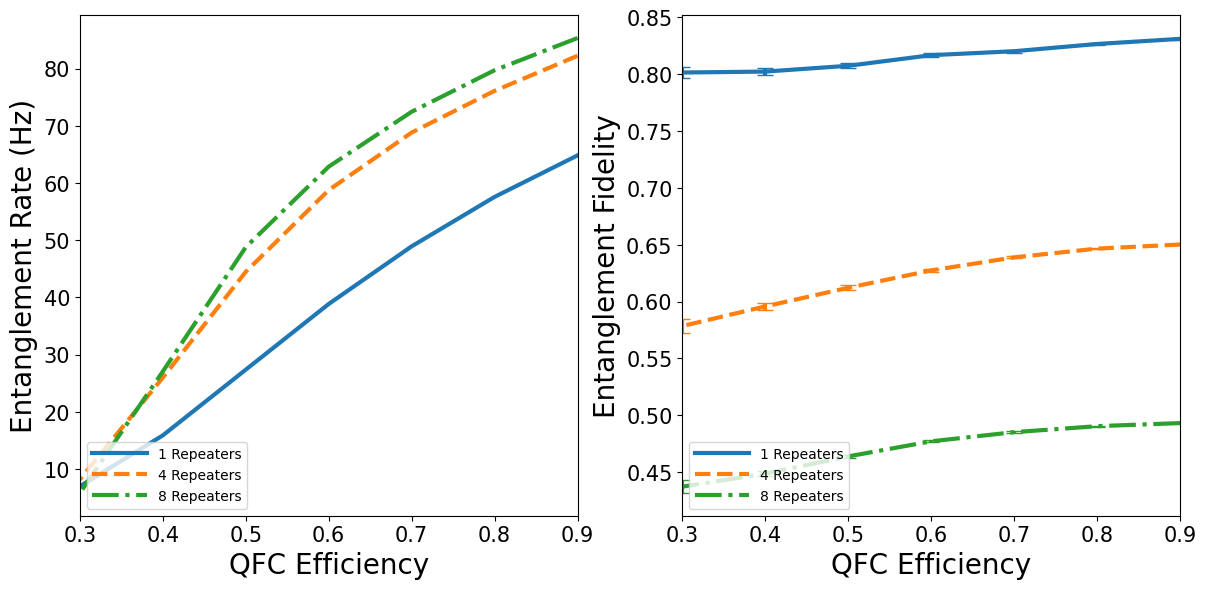

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Load the CSV file
df = pd.read_csv('rate/agg_qfc.csv')  # Adjust delimiter if needed
df = df[df['num_repeaters'].isin([1, 4, 8])]  # Filter for specific repeater numbers

# Define different line styles for each repeater count
line_styles = {1: 'solid', 4: 'dashed', 8: 'dashdot'}

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. QFC Efficiency (First Plot)
for repeater in df['num_repeaters'].unique():
    subset = df[df['num_repeaters'] == repeater]
    ax[0].plot((1-subset['init_photon_loss']), subset['rate'],
                label=f'{repeater} Repeaters', linestyle=line_styles[repeater])

# ax[0].set_ylim(0, df['rate'].max() * 1.1)  # Dynamically adjust the y-limit
ax[0].set_xlim(0.3, 0.9)
ax[0].set_xlabel('QFC Efficiency')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(loc='lower left', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. QFC Efficiency (Second Plot)
for repeater in df['num_repeaters'].unique():  # Iterate over each repeater count
    subset = df[df['num_repeaters'] == repeater]
    
    # X and Y values for plotting
    x = 1 - subset['init_photon_loss']  # QFC Efficiency (1 - qfc_loss)
    y = subset['fidelity']  # Fidelity values
    yerr = subset['sem']  # Standard error values
    
    # Add error bars to the fidelity plot
    ax[1].errorbar(x, y, yerr=yerr, label=f'{repeater} Repeaters', linestyle=line_styles[repeater], capsize=6,
        elinewidth=3)

# ax[1].set_ylim(0.7, 1)
ax[1].set_xlim(0.3, 0.9)
ax[1].set_xlabel('QFC Efficiency')
ax[1].set_ylabel('Entanglement Fidelity')
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left', handlelength=3.9)
# ax[1].legend(loc='lower left', prop={'size': 12})

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('qfc_comparison_plot.pdf', format='pdf')
plt.show()

## Fiber Loss

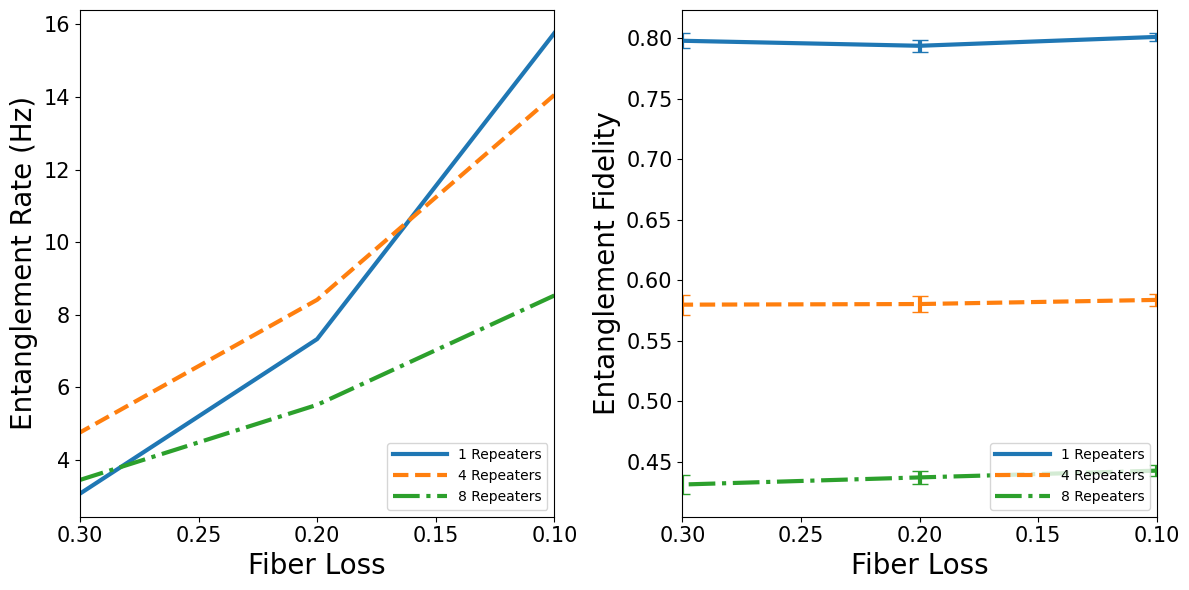

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Load the CSV file
df = pd.read_csv('rate/agg_fib_loss.csv')  # Adjust delimiter if needed
df = df[df['num_repeaters'].isin([1, 4, 8])]  # Filter for specific repeater numbers

# Define different line styles for each repeater count
line_styles = {1: 'solid', 4: 'dashed', 8: 'dashdot'}

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. QFC Efficiency (First Plot)
for repeater in df['num_repeaters'].unique():
    subset = df[df['num_repeaters'] == repeater]
    ax[0].plot((subset['photon_loss']), subset['rate'],
                label=f'{repeater} Repeaters', linestyle=line_styles[repeater])

# ax[0].set_ylim(0, df['rate'].max() * 1.1)  # Dynamically adjust the y-limit
ax[0].set_xlim(0.3, 0.1)
ax[0].set_xlabel('Fiber Loss')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(loc='lower right', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. QFC Efficiency (Second Plot)
for repeater in df['num_repeaters'].unique():  # Iterate over each repeater count
    subset = df[df['num_repeaters'] == repeater]
    
    # X and Y values for plotting
    x = subset['photon_loss']  # QFC Efficiency (1 - qfc_loss)
    y = subset['fidelity']  # Fidelity values
    yerr = subset['sem']  # Standard error values
    
    # Add error bars to the fidelity plot
    ax[1].errorbar(x, y, yerr=yerr, label=f'{repeater} Repeaters', linestyle=line_styles[repeater], capsize=6,
        elinewidth=3)

# ax[1].set_ylim(0, 1)
ax[1].set_xlim(0.3, 0.1)
ax[1].set_xlabel('Fiber Loss')
ax[1].set_ylabel('Entanglement Fidelity')
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower right', handlelength=3.9)
# ax[1].legend(loc='lower left', prop={'size': 12})

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('fiber_comparison_plot.pdf', format='pdf')
plt.show()

## Collection Efficiency

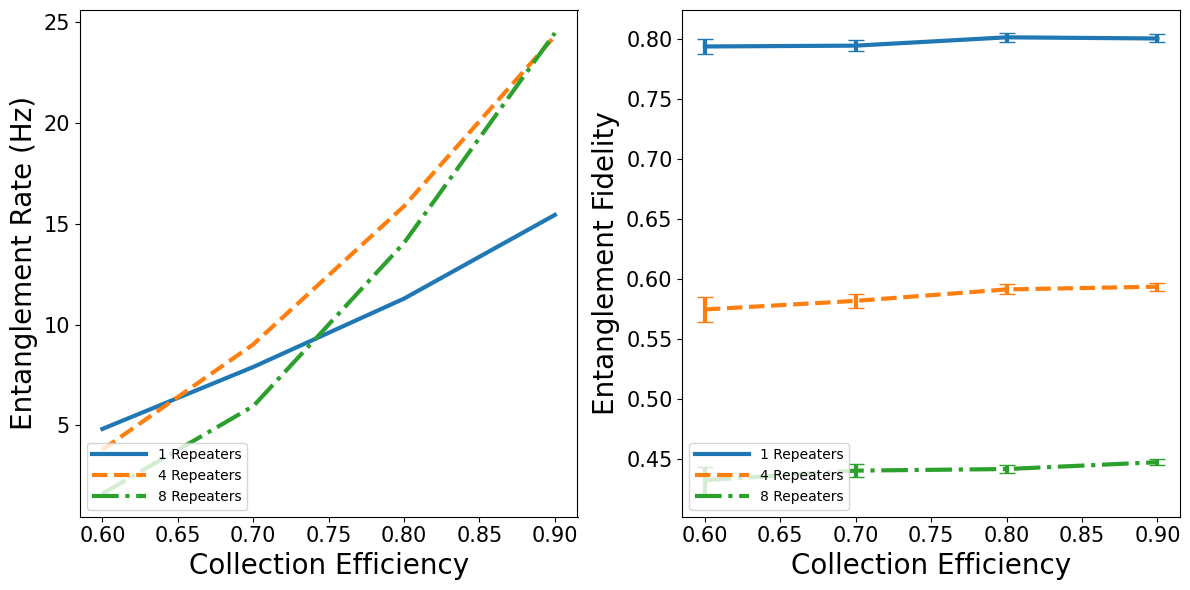

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Load the CSV file
df = pd.read_csv('rate/agg_coll_eff.csv')  # Adjust delimiter if needed
df = df[df['num_repeaters'].isin([1, 4, 8])]  # Filter for specific repeater numbers

# Define different line styles for each repeater count
line_styles = {1: 'solid', 4: 'dashed', 8: 'dashdot'}

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. QFC Efficiency (First Plot)
for repeater in df['num_repeaters'].unique():
    subset = df[df['num_repeaters'] == repeater]
    ax[0].plot((subset['collection_efficiency']), subset['rate'],
                label=f'{repeater} Repeaters', linestyle=line_styles[repeater])

# ax[0].set_ylim(0, df['rate'].max() * 1.1)  # Dynamically adjust the y-limit
# ax[0].set_xlim(0.3, 0.9)
ax[0].set_xlabel('Collection Efficiency')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(loc='lower left', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. QFC Efficiency (Second Plot)
for repeater in df['num_repeaters'].unique():  # Iterate over each repeater count
    subset = df[df['num_repeaters'] == repeater]
    
    # X and Y values for plotting
    x = subset['collection_efficiency']  # QFC Efficiency (1 - qfc_loss)
    y = subset['fidelity']  # Fidelity values
    yerr = subset['sem']  # Standard error values
    
    # Add error bars to the fidelity plot
    ax[1].errorbar(x, y, yerr=yerr, label=f'{repeater} Repeaters', linestyle=line_styles[repeater], capsize=6,
        elinewidth=3)

# ax[1].set_ylim(0.7, 1)
# ax[1].set_xlim(0.3, 0.9)
ax[1].set_xlabel('Collection Efficiency')
ax[1].set_ylabel('Entanglement Fidelity')
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left', handlelength=3.9)
# ax[1].legend(loc='lower left', prop={'size': 12})

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('qfc_comparison_plot.pdf', format='pdf')
plt.show()

## Protocol Type

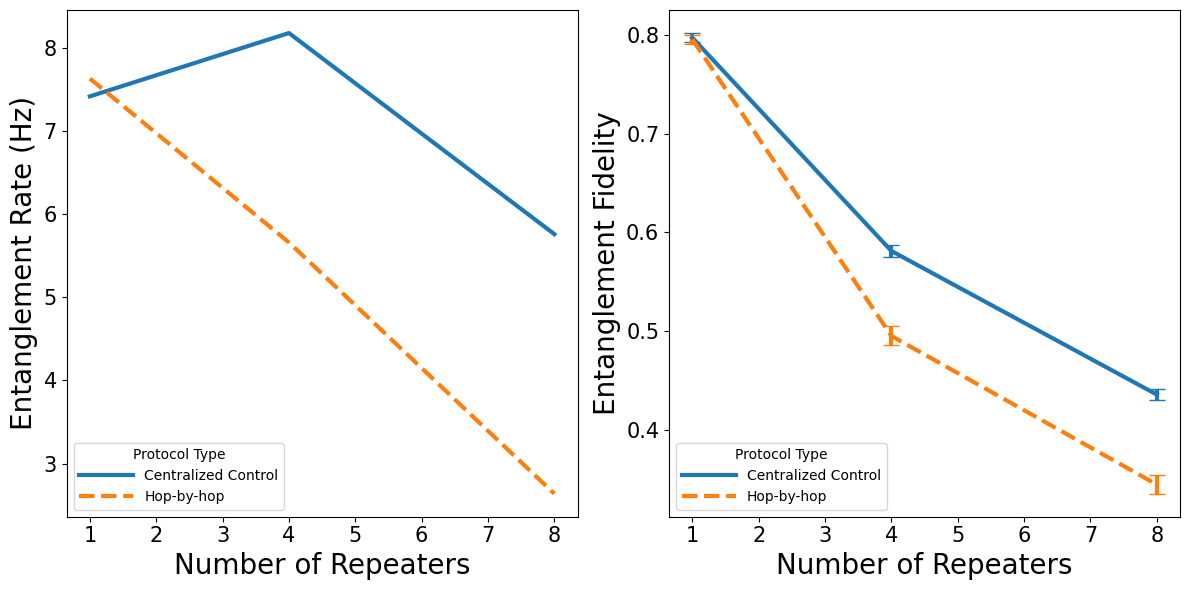

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('rate/agg_proto_sched.csv')

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15) 

# Update the missing value
# mask = (data['protocol'] == 1) & (data['num_repeaters'] == 2)
# data.loc[mask, 'rate'] = 34.56
# data.loc[mask, 'fidelity'] = 0.6240864861578301

# Define different line styles for each protocol
proto_sched = {1: 'solid', 3: 'dashed'}  # Protocol 1 = solid, Protocol 3 = dashed

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Fidelity vs. Number of Repeaters
# Plot Rate vs. Number of Repeaters (Now ax[0])
for proto in data['proto_sched'].unique():
    if proto == 2:  # Skip protocol 2
        continue
    label = "Centralized Control" if proto == 1 else ("Hop-by-hop" if proto == 3 else f"Protocol {proto}")
    subset = data[data['proto_sched'] == proto]
    ax[0].errorbar(subset['num_repeaters'], subset['rate'], label=label, linestyle=proto_sched.get(proto, 'solid'))
# ax[0].set_ylim(0, 40)
ax[0].set_xlabel('Number of Repeaters')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(title='Protocol Type', loc='lower left', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. Number of Repeaters (Now ax[1])
for proto in data['proto_sched'].unique():
    if proto == 2:  # Skip protocol 2
        continue
    label = "Centralized Control" if proto == 1 else ("Hop-by-hop" if proto == 3 else f"Protocol {proto}")
    subset = data[data['proto_sched'] == proto]
    yerr = subset['sem'].values  # Assuming 'sem' column exists in your data

    ax[1].errorbar(
        subset['num_repeaters'], 
        subset['fidelity'], 
        yerr=yerr,  # Standard error
        label=label, 
        linestyle=proto_sched.get(proto, 'solid'),
        capsize=6, 
        elinewidth=3
    # )
# get handles
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left',title="Protocol Type", handlelength=3.9)
# ax[1].set_ylim(0, 1)
ax[1].set_xlabel('Number of Repeaters')
ax[1].set_ylabel('Entanglement Fidelity')
# ax[1].legend(title='Protocol Type', loc="lower left", handlelength=3.9)
# ax[1].grid(True)

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('proto_comparison_plot.pdf', format='pdf')
plt.show()

## Coherence Time

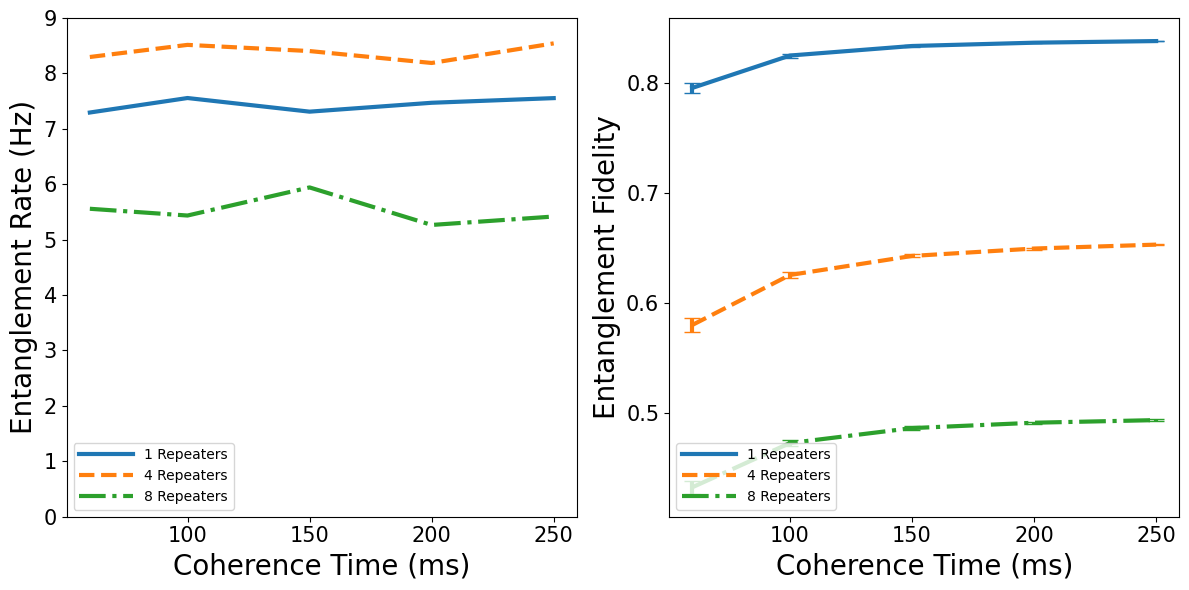

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Load the CSV file
df = pd.read_csv('fidelity/agg_ct.csv')  # Adjust delimiter if needed
df = df[df['num_repeaters'].isin([1, 4, 8])]  # Filter for specific repeater numbers

# Define different line styles for each repeater count
line_styles = {1: 'solid', 4: 'dashed', 8: 'dashdot'}

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. QFC Efficiency (First Plot)
for repeater in df['num_repeaters'].unique():
    subset = df[df['num_repeaters'] == repeater]
    ax[0].plot((subset['coherence_time']/1e6), subset['rate'],
                label=f'{repeater} Repeaters', linestyle=line_styles[repeater])

# ax[0].set_ylim(0, df['rate'].max() * 1.1)  # Dynamically adjust the y-limit
ax[0].set_ylim(0, 9)
ax[0].set_xlabel('Coherence Time (ms)')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(loc='lower left', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. QFC Efficiency (Second Plot)
for repeater in df['num_repeaters'].unique():  # Iterate over each repeater count
    subset = df[df['num_repeaters'] == repeater]
    
    # X and Y values for plotting
    x = subset['coherence_time']/1e6  # QFC Efficiency (1 - qfc_loss)
    y = subset['fidelity']  # Fidelity values
    yerr = subset['sem']  # Standard error values
    
    # Add error bars to the fidelity plot
    ax[1].errorbar(x, y, yerr=yerr, label=f'{repeater} Repeaters', linestyle=line_styles[repeater], capsize=6,
        elinewidth=3)

# ax[1].set_ylim(0.7, 1)
# ax[1].set_xlim(0.3, 0.9)
ax[1].set_xlabel('Coherence Time (ms)')
ax[1].set_ylabel('Entanglement Fidelity')
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left', handlelength=3.9)
# ax[1].legend(loc='lower left', prop={'size': 12})

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('qfc_comparison_plot.pdf', format='pdf')
plt.show()

## Emission Fidelity

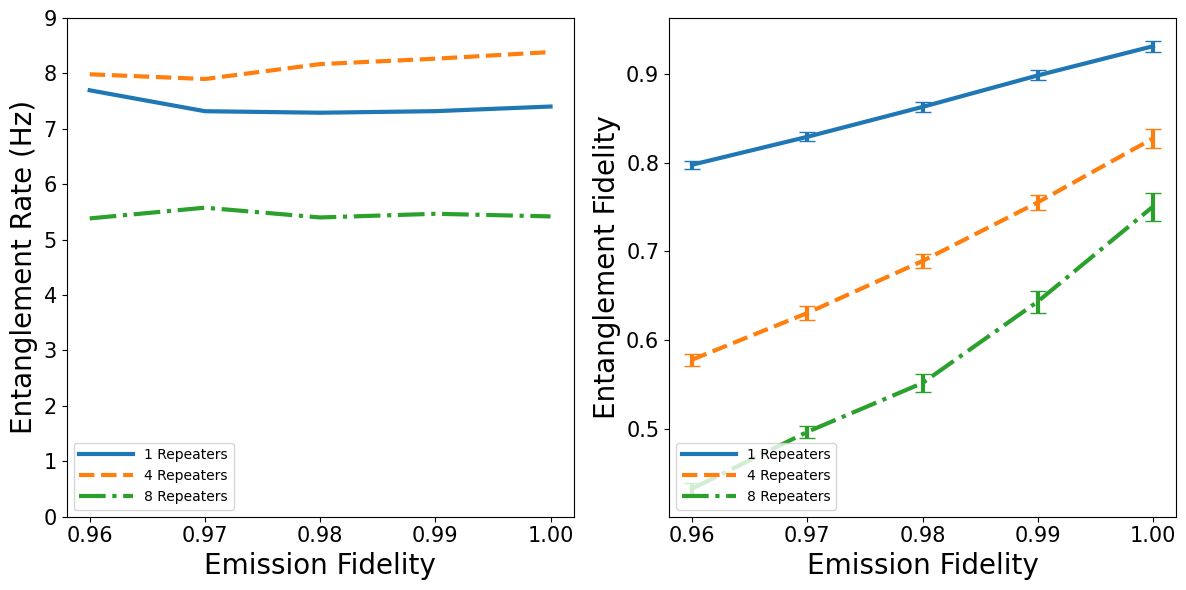

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Load the CSV file
df = pd.read_csv('fidelity/agg_em_fid.csv')  # Adjust delimiter if needed
df = df[df['num_repeaters'].isin([1, 4, 8])]  # Filter for specific repeater numbers

# Define different line styles for each repeater count
line_styles = {1: 'solid', 4: 'dashed', 8: 'dashdot'}

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. QFC Efficiency (First Plot)
for repeater in df['num_repeaters'].unique():
    subset = df[df['num_repeaters'] == repeater]
    ax[0].plot((subset['emission_fidelity']), subset['rate'],
                label=f'{repeater} Repeaters', linestyle=line_styles[repeater])

# ax[0].set_ylim(0, df['rate'].max() * 1.1)  # Dynamically adjust the y-limit
ax[0].set_ylim(0, 9)
ax[0].set_xlabel('Emission Fidelity')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(loc='lower left', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. QFC Efficiency (Second Plot)
for repeater in df['num_repeaters'].unique():  # Iterate over each repeater count
    subset = df[df['num_repeaters'] == repeater]
    
    # X and Y values for plotting
    x = subset['emission_fidelity']  # QFC Efficiency (1 - qfc_loss)
    y = subset['fidelity']  # Fidelity values
    yerr = subset['sem']  # Standard error values
    
    # Add error bars to the fidelity plot
    ax[1].errorbar(x, y, yerr=yerr, label=f'{repeater} Repeaters', linestyle=line_styles[repeater], capsize=6,
        elinewidth=3)

# ax[1].set_ylim(0.7, 1)
# ax[1].set_xlim(0.3, 0.9)
ax[1].set_xlabel('Emission Fidelity')
ax[1].set_ylabel('Entanglement Fidelity')
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left', handlelength=3.9)
# ax[1].legend(loc='lower left', prop={'size': 12})

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('qfc_comparison_plot.pdf', format='pdf')
plt.show()

## MS Gate Fidelity

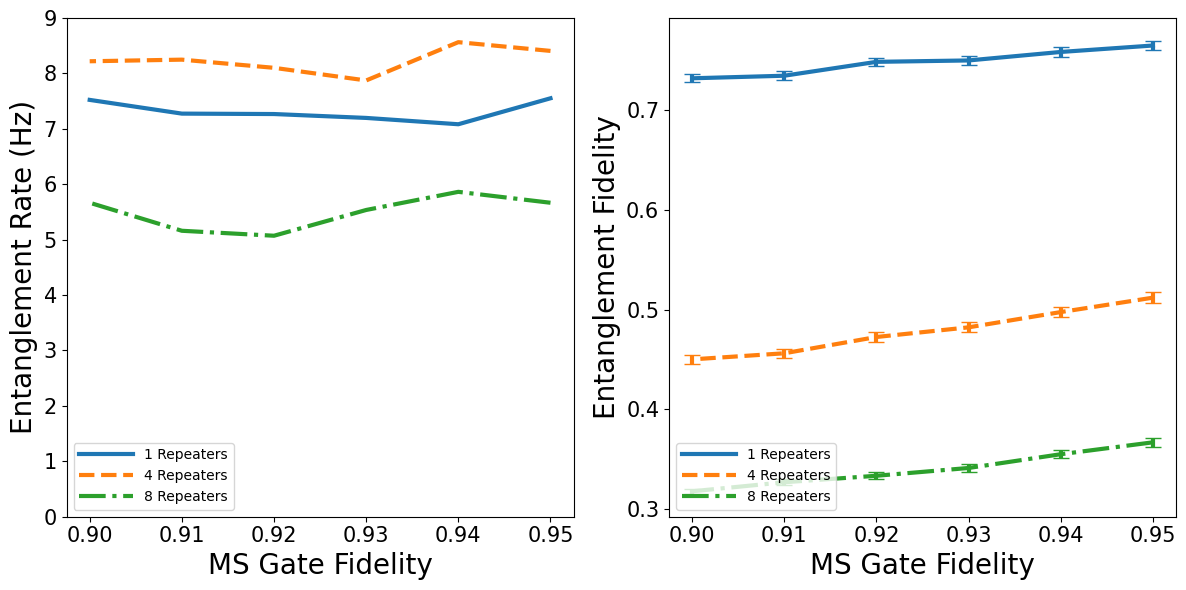

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Load the CSV file
df = pd.read_csv('fidelity/agg_ms_fid.csv')  # Adjust delimiter if needed
df = df[df['num_repeaters'].isin([1, 4, 8])]  # Filter for specific repeater numbers

# Define different line styles for each repeater count
line_styles = {1: 'solid', 4: 'dashed', 8: 'dashdot'}

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. QFC Efficiency (First Plot)
for repeater in df['num_repeaters'].unique():
    subset = df[df['num_repeaters'] == repeater]
    ax[0].plot((1-subset['ms_depolar_prob']), subset['rate'],
                label=f'{repeater} Repeaters', linestyle=line_styles[repeater])

# ax[0].set_ylim(0, df['rate'].max() * 1.1)  # Dynamically adjust the y-limit
ax[0].set_ylim(0, 9)
ax[0].set_xlabel('MS Gate Fidelity')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(loc='lower left', handlelength=3.9)
# ax[0].grid(True)

# Plot Fidelity vs. QFC Efficiency (Second Plot)
for repeater in df['num_repeaters'].unique():  # Iterate over each repeater count
    subset = df[df['num_repeaters'] == repeater]
    
    # X and Y values for plotting
    x = 1-subset['ms_depolar_prob']  # QFC Efficiency (1 - qfc_loss)
    y = subset['fidelity']  # Fidelity values
    yerr = subset['sem']  # Standard error values
    
    # Add error bars to the fidelity plot
    ax[1].errorbar(x, y, yerr=yerr, label=f'{repeater} Repeaters', linestyle=line_styles[repeater], capsize=6,
        elinewidth=3)

# ax[1].set_ylim(0.7, 1)
# ax[1].set_xlim(0.3, 0.9)
ax[1].set_xlabel('MS Gate Fidelity')
ax[1].set_ylabel('Entanglement Fidelity')
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left', handlelength=3.9)
# ax[1].legend(loc='lower left', prop={'size': 12})

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('qfc_comparison_plot.pdf', format='pdf')
plt.show()

## Retries

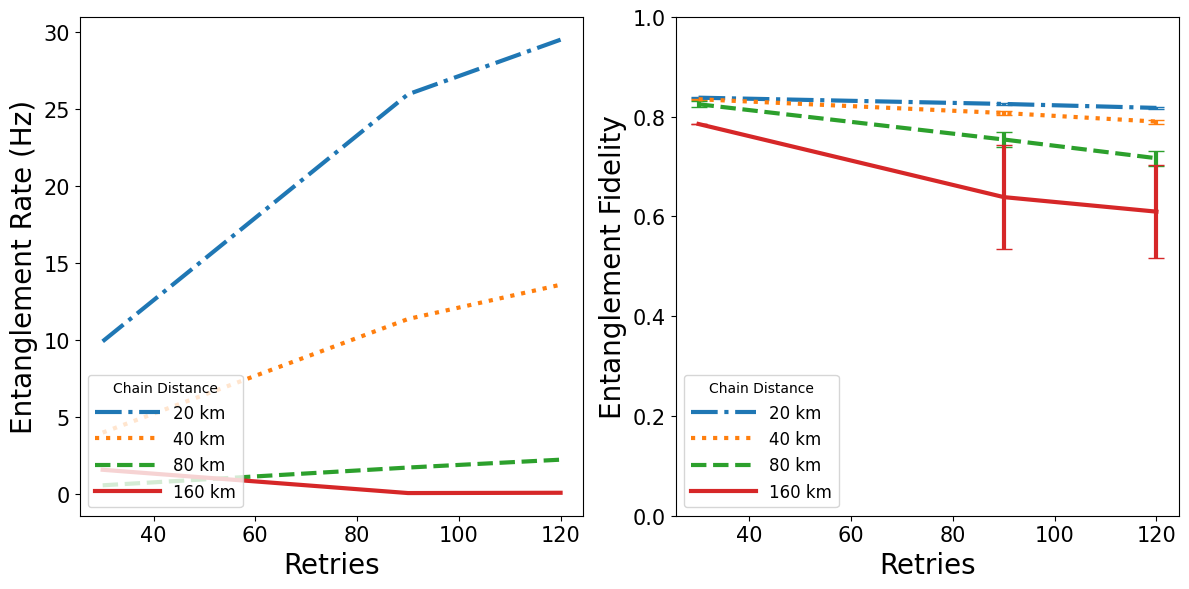

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size

# Define different line styles for retries
line_styles = {80: 'dashed', 160: 'solid', 20: 'dashdot', 40: 'dotted'}
colors = {30: 'black', 90: 'grey', 120: 'dimgrey'}

# List of sets with corresponding CSV file names (the aggregated files)
sets = {
    # "fid_retries": ['fid_retries_agg.csv'],
    "1tr_rate_retries": ['retries/results_by_distance_retries.csv'],
}

# Function to process a single set and plot based on type
def plot_based_on_type(set_name, agg_files, layout='side_by_side'):
    # Load the aggregated CSV file into a DataFrame
    dfs = [pd.read_csv(file) for file in agg_files]
    
    # Concatenate the DataFrames
    merged_df = pd.concat(dfs, ignore_index=True)
    
    # Filter for retries = 30, 90, 120
    filtered_df = merged_df[merged_df['retries'].isin([30, 90, 120])]
    
    # Define subplot layout
    if layout == 'side_by_side':   # Horizontal layout (1 row, 2 columns)
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    else:                          # Vertical layout (2 rows, 1 column)
        fig, ax = plt.subplots(2, 1, figsize=(6, 12))

    # Plot both graphs
    plot_rate_vs_distance(filtered_df, ax[0])
    plot_fid_vs_distance(filtered_df, ax[1])
    handles, labels = ax[1].get_legend_handles_labels()

    # remove the errorbars (only keep line handles)
    handles = [h[0] for h in handles]  # Only keep the lines (remove error bars)

    # use them in the legend
    ax[1].legend(handles, labels, loc='best', title="Chain Distance", prop={'size': 12}, handlelength=3.9)

    # Save and show the plot
    plt.tight_layout()
    # plt.savefig('retries_plot.pdf', format='pdf')
    plt.show()

# Plot rate vs distance
def plot_rate_vs_distance(df, ax):
    for dist in [20, 40, 80, 160]:
        subset = df[df['distance'] == dist]
        if not subset.empty:
            ax.plot(subset['retries'], subset['rate'], 
                    label=f'{dist} km', 
                    linestyle=line_styles[dist])
                    # color=colors[retries])
    
    ax.set_xlabel("Retries")
    ax.set_ylabel("Entanglement Rate (Hz)")
    ax.legend(title='Chain Distance',loc="lower left", prop={'size': 12}, handlelength=3.9)
    ax.ticklabel_format(axis='y')

# Plot fidelity vs distance
def plot_fid_vs_distance(df, ax):
    for dist in [20, 40, 80, 160]:
        subset = df[df['distance'] == dist]
        if not subset.empty:
            yerr = subset['sem'].values  # Assuming 'sem' column contains standard error values
            ax.errorbar(subset['retries'], subset['fidelity'], 
                        yerr=yerr,
                        label=f'{dist} km',  # Display scaled distance in the label
                        linestyle=line_styles[dist],capsize=6,
        elinewidth=3)
    
    ax.set_xlabel("Retries")
    ax.set_ylabel("Entanglement Fidelity")
    ax.set_ylim(0, 1)
    ax.legend(title='Chain Distance', loc="lower left", prop={'size': 12}, handlelength=3.9)

# Process each set and plot the graphs
for set_name, files in sets.items():
    plot_based_on_type(set_name, files, layout='side_by_side')  # Change to 'vertical' for stacked layout

## Rate and fidelity

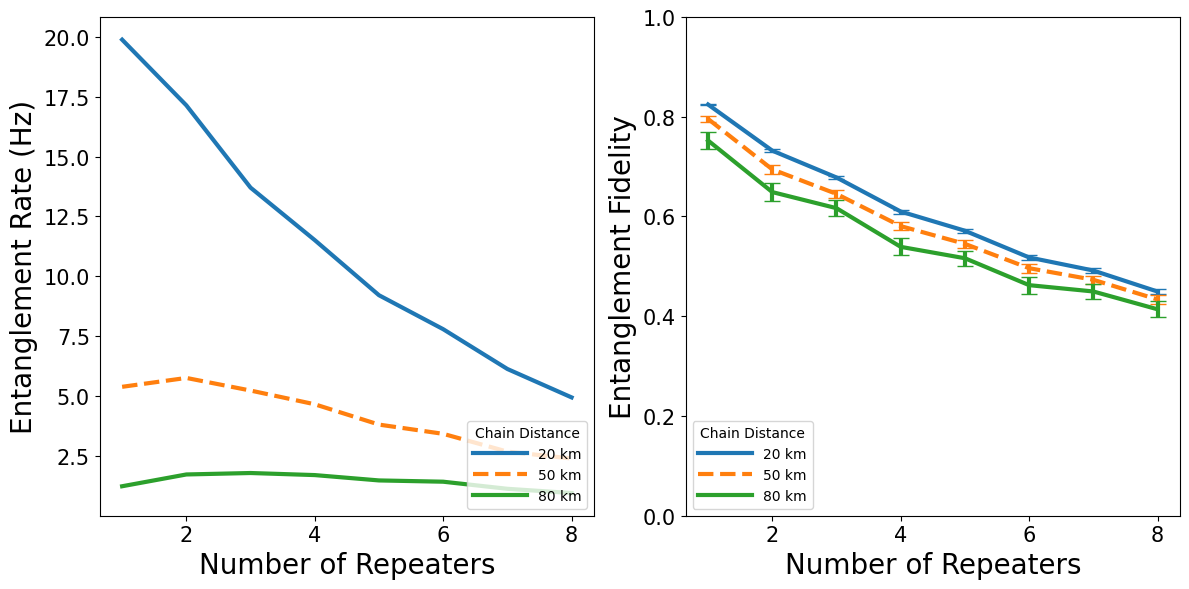

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('rate_fid/results_all_distances_repeaters.csv')

# Set global plot formatting
plt.rc('axes', labelsize=20)       # Axis label font size
plt.rc('lines', linewidth=3.0)     # Line width
plt.rc('xtick', labelsize=15)      # X-axis tick label size
plt.rc('ytick', labelsize=15)      # Y-axis tick label size


# Define different line styles for each distance
line_styles = {10: 'solid', 50: 'dashed', 100: 'dashdot'}  # Example distances with different linestyles

# Create subplots for side-by-side plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot Rate vs. Number of Repeaters with Distance as Label (Now ax[0])
for dist in data['distance'].unique():
    subset = data[data['distance'] == dist]
    label = f'{dist} km'  # Use distance as label
    ax[0].errorbar(subset['num_repeaters'], subset['rate'], label=label, linestyle=line_styles.get(dist, 'solid'))
# ax[0].set_ylim(0, 70)
ax[0].set_xlabel('Number of Repeaters')
ax[0].set_ylabel('Entanglement Rate (Hz)')
ax[0].legend(title='Chain Distance', loc='lower right', handlelength=3.9)

# Plot Fidelity vs. Number of Repeaters with Distance as Label (Now ax[1])
for dist in data['distance'].unique():
    subset = data[data['distance'] == dist]
    x = subset['num_repeaters'].values
    y = subset['fidelity'].values
    yerr = subset['sem'].values
    ax[1].errorbar(
        x,
        y,
        yerr=yerr,
        # fmt='o-',
        label=f'{dist} km', 
        linestyle=line_styles.get(dist, 'solid'),
        capsize=6,
        elinewidth=3
    )
ax[1].set_ylim(0, 1)
ax[1].set_xlabel('Number of Repeaters')
ax[1].set_ylabel('Entanglement Fidelity')
# get handles
handles, labels = ax[1].get_legend_handles_labels()
# remove the errorbars
handles = [h[0] for h in handles]
# use them in the legend
ax[1].legend(handles, labels,loc='lower left',title="Chain Distance", handlelength=3.9)
# ax[1].legend(title='Distance (km)', loc='lower right', handlelength=3.9)

# Adjust layout and display the plots
plt.tight_layout()
# plt.savefig('1G_comparison.pdf', format='pdf')
plt.show()